Mean: 4.533180768041381
Variance: 8.471752995689984
Skewness: 0.7333922713453493
Kurtosis: 0.632539613099377
Minimum: 1e-15
Maximum: 28.565421179973644
Quantiles: [2.35194055 4.2027553  6.29832775]
Standard Deviation: 2.910627594813528
Median: 4.202755303692901
95th Percentile: 9.834003090565835
99th Percentile: 12.73600372052317
Histogram: (array([68324, 49324, 57546, 66430, 73250, 77604, 79535, 77765, 73170,
       66425, 59260, 50838, 42615, 35583, 28599, 22628, 17835, 13678,
       10341,  7917,  5947,  4347,  3194,  2320,  1687,  1138,   842,
         568,   360,   285,   179,   148,   104,    77,    43,    37,
          18,    14,     5,     4,     6,     1,     4,     3,     0,
           1,     0,     0,     0,     1]), array([1.00000000e-15, 5.71308424e-01, 1.14261685e+00, 1.71392527e+00,
       2.28523369e+00, 2.85654212e+00, 3.42785054e+00, 3.99915897e+00,
       4.57046739e+00, 5.14177581e+00, 5.71308424e+00, 6.28439266e+00,
       6.85570108e+00, 7.42700951e+00, 7.99831793

(array([1.19592145e-01, 8.63351527e-02, 1.00726679e-01, 1.16276948e-01,
        1.28214458e-01, 1.35835561e-01, 1.39215521e-01, 1.36117370e-01,
        1.28074429e-01, 1.16268196e-01, 1.03726809e-01, 8.89852099e-02,
        7.45919336e-02, 6.22833456e-02, 5.00587753e-02, 3.96073278e-02,
        3.12178138e-02, 2.39415339e-02, 1.81005558e-02, 1.38576637e-02,
        1.04094387e-02, 7.60884983e-03, 5.59067549e-03, 4.06085383e-03,
        2.95287087e-03, 1.99191882e-03, 1.47380988e-03, 9.94209041e-04,
        6.30132491e-04, 4.98854889e-04, 3.13315877e-04, 2.59054468e-04,
        1.82038275e-04, 1.34778338e-04, 7.52658253e-05, 6.47636171e-05,
        3.15066245e-05, 2.45051524e-05, 8.75184015e-06, 7.00147212e-06,
        1.05022082e-05, 1.75036803e-06, 7.00147212e-06, 5.25110409e-06,
        0.00000000e+00, 1.75036803e-06, 0.00000000e+00, 0.00000000e+00,
        0.00000000e+00, 1.75036803e-06]),
 array([1.00000000e-15, 5.71308424e-01, 1.14261685e+00, 1.71392527e+00,
        2.28523369e+00

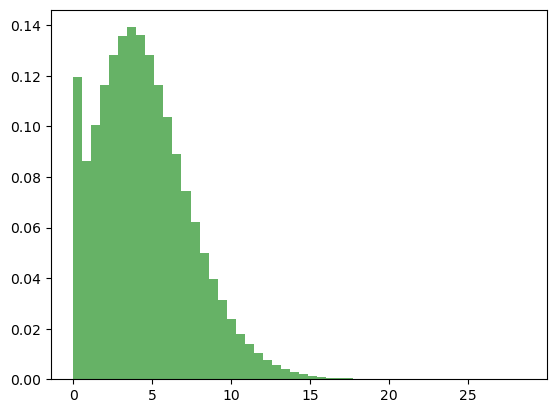

In [2]:
import numpy as np
import scipy.stats as st
import matplotlib.pyplot as plt
def exp_levy_dist(alpha = 1.37, beta = -1.00, loc = 0.92, scale = 0.44, size = 1):
	return np.exp(st.levy_stable.rvs(alpha = alpha, beta = beta, loc = loc, scale = scale, size = size)) + 1e-15

samples = exp_levy_dist(size = 1000000)
print("Mean:", np.mean(samples))
print("Variance:", np.var(samples))
print("Skewness:", st.skew(samples))
print("Kurtosis:", st.kurtosis(samples))
print("Minimum:", np.min(samples))
print("Maximum:", np.max(samples))
print("Quantiles:", np.quantile(samples, [0.25, 0.5, 0.75]))
print("Standard Deviation:", np.std(samples))
print("Median:", np.median(samples))
# print("Mode:", st.mode(samples)[0][0])
print("95th Percentile:", np.percentile(samples, 95))
print("99th Percentile:", np.percentile(samples, 99))
print("Histogram:", np.histogram(samples, bins=50))
print("Sample Size:", len(samples))
print("First 10 Samples:", samples[:10])
print("Last 10 Samples:", samples[-10:])
plt.hist(samples, bins=50, density=True, alpha=0.6, color='g')

Perisomatic Inhibitory Firing Rate:
Mean: 16.895772325533382
Standard Deviation: 3.5777259893950237
Median: 16.892812686238827
Distal Inhibitory Firing Rate:
Mean: 3.9021582982430925
Standard Deviation: 1.219020744918479
Median: 3.8994846949946647


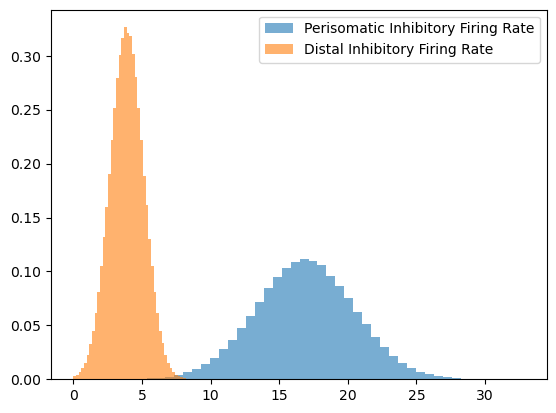

In [6]:
inh_fr_params = {
    'perisomatic': {'mean': 16.9, 'std': 14.3*0.25},
    'distal': {'mean': 3.9, 'std':4.9*0.25},
}

for inh_fr, params in inh_fr_params.items():
    mean_fr = params['mean']
    std_fr = params['std']
    a, b = (0 - mean_fr) / std_fr, (100 - mean_fr) / std_fr
    args = {'a': a, 'b': b, 'loc': mean_fr, 'scale': std_fr}
    sample = st.truncnorm.rvs(**args, size=1000000)
    
    print(f"{inh_fr.capitalize()} Inhibitory Firing Rate:")
    print("Mean:", np.mean(sample))
    # print("Variance:", np.var(sample))
    # print("Skewness:", st.skew(sample))
    # print("Kurtosis:", st.kurtosis(sample))
    # print("Minimum:", np.min(sample))
    # print("Maximum:", np.max(sample))
    # print("Quantiles:", np.quantile(sample, [0.25, 0.5, 0.75]))
    print("Standard Deviation:", np.std(sample))
    print("Median:", np.median(sample))
    # print("Mode:", st.mode(sample)[0][0])
    # print("95th Percentile:", np.percentile(sample, 95))
    # print("99th Percentile:", np.percentile(sample, 99))
    # print("Histogram:", np.histogram(sample, bins=50))
    # print("Sample Size:", len(sample))
    # print("First 10 Samples:", sample[:10])
    # print("Last 10 Samples:", sample[-10:])
    plt.hist(sample, bins=50, density=True, alpha=0.6, label=f'{inh_fr.capitalize()} Inhibitory Firing Rate')
    plt.legend()